In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from figures_setup import *

# CRC cohort PDOX-seq

## Getting data from arrayExpress: E-MTAB-16585

In [17]:
# Download data from arrayExpress and reassemble anndata object
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16585"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset = 'epi',
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16585 in: ../data_arrayExpress/E-MTAB-16585
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16585
      Inferred 2 dataset representations:
      - epi (full prefix: biobank_subcut_epi)
      - full (full prefix: biobank_subcut_full)
      Selected dataset for in-memory loading: epi (full prefix: biobank_subcut_epi)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_epi.h5ad
      Already exists, skipping rebuild: E-MTAB-16585/E-MTAB-16585_full.h5ad
      Loading selected dataset from disk: E-MTAB-16585/E-MTAB-16585_epi.h5ad


AnnData object with n_obs × n_vars = 10135 × 27111
    obs: 'sample_id', 'donor_id', 'library_id', 'batch', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## Comparison TROP2+ vs TROP2- cells 

This dataset has been analyzed with decoupler version 1.8.0. In the meantime, decoupler has been upgrade to version 2.0.6 (or higher) which was used in more recent datasets.

In [18]:
import decoupler as dc
dc.__version__

'1.8.0'

In [19]:
# Import literature gene sets to adata.uns
from utils import get_gene_sets
print("Importing gene sets into anndata object...")
adata = get_gene_sets(adata, verbose=False)

Importing gene sets into anndata object...


### Pseudobulk generation

In [20]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata)

In [21]:
# Add TROP2 status column based on 'TROP2_pos' boolean column
adata.obs['TROP2_status'] = ['TROP2_pos' if x else 'TROP2_neg' for x in adata.obs['TACSTD2_pos']]
adata.obs['TROP2_status'].value_counts()

TROP2_status
TROP2_neg    7828
TROP2_pos    2307
Name: count, dtype: int64

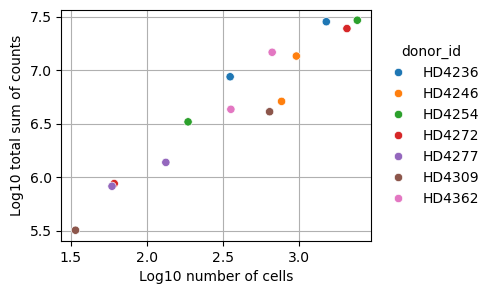

In [22]:
### Generate pseudobulks

# Define minimum number of cells and counts for pseudobulk
min_cells = 20
min_counts = 5e4

### Compute pseudobulk profiles
sample_col = 'donor_id'
group_col = ['TROP2_status']
pdata = dc.get_pseudobulk(
    adata,
    sample_col=sample_col,
    groups_col=group_col,
    layer='counts',
    mode='sum',
    min_cells=min_cells,
    min_counts=min_counts,
)


### Visualize pseudobulk profiles
# Not part of manuscript
dc.plot_psbulk_samples(pdata, groupby=sample_col, figsize=(4, 3))

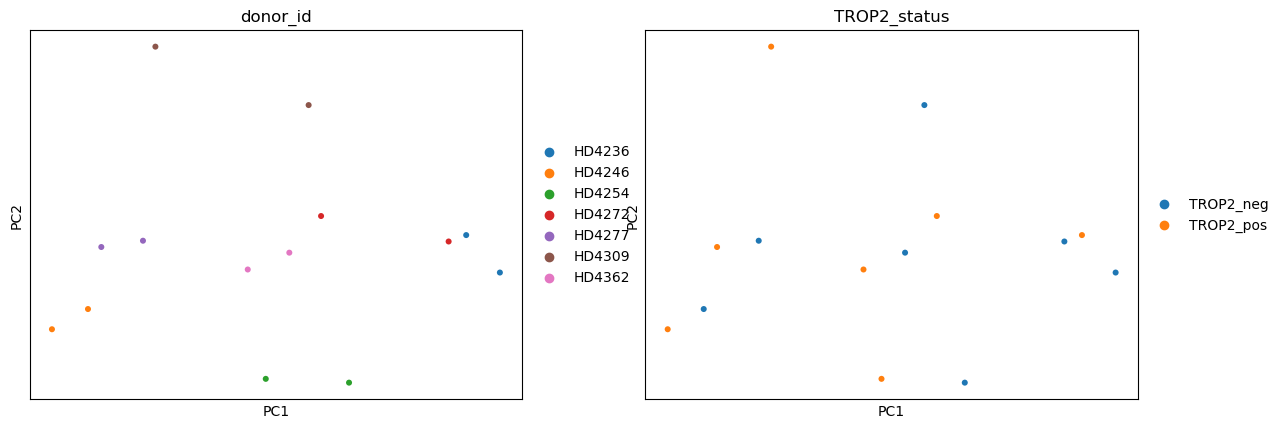

In [23]:
### Compute PCA on pseudobulk data
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)


### Visualize data on PCA
# Not part of manuscript
sc.pl.pca(pdata, color=[sample_col] + group_col, ncols=2, size=75)

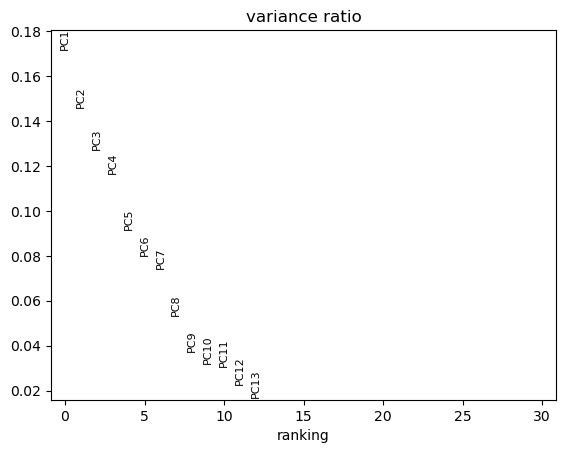

In [24]:
### Plot variance explained by PCs
# Not part of manuscript
sc.pl.pca_variance_ratio(pdata)

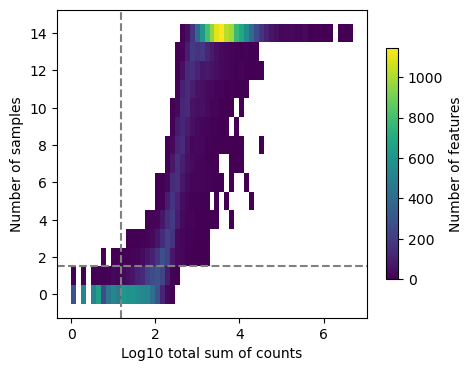

In [25]:
### Filter genes by expression
min_count = 10
min_total_count = 15
dc.plot_filter_by_expr(pdata, group=sample_col, min_count=min_count, min_total_count=min_total_count)
genes = dc.filter_by_expr(pdata, group=sample_col, min_count=min_count, min_total_count=min_total_count)

In [26]:
### Save pseudobulk data
pdata = pdata[:, genes].copy()
print(pdata.shape)
# Remove binary values from obs
del pdata.obs['TACSTD2_pos']
pdata.write_h5ad(os.path.join(dir_data, f"{accession}_pdata.h5ad"))
pdata

(14, 17606)


AnnData object with n_obs × n_vars = 14 × 17606
    obs: 'donor_id', 'TROP2_status', 'psbulk_n_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'donor_id_colors', 'TROP2_status_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

### DGEA on pseudobulks

In [27]:
import decoupler as dc

# # Read pseudobulk data
# accession = "E-MTAB-16585"
# pdata = sc.read_h5ad(os.path.join(dir_data, f"{accession}_pdata.h5ad"))

In [28]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [29]:
# Set up DGEA comparison
design = 'TROP2_status'
design_ref = 'TROP2_neg'

In [30]:
# Create DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pdata,
    design_factors=design,
    ref_level=[design, design_ref],
    refit_cooks=True,
    inference=inference,
)

/tmp/ipykernel_1419169/2903302091.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(
/omics/groups/OE0285/internal/puschhof/envs/env_saez/lib/python3.10/site-packages/pydeseq2/dds.py:264: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


In [31]:
# Dispersion and LFC estimation 
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.45 seconds.

Fitting dispersion trend curve...
... done in 5.58 seconds.

Fitting MAP dispersions...
... done in 2.74 seconds.

Fitting LFCs...
... done in 1.96 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 308 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.07 seconds.



In [32]:
### Contrast between conditions

# Replace design underscores with dashes for DeseqStats compatibility
design = design.replace("_", "-")
design_ref = design_ref.replace("_", "-")

### Contrast between conditions
cond = 'TROP2-pos'
print(f"Contrasting with test condition {cond}")
stat_res = DeseqStats(
    dds,
    contrast=[design, cond, design_ref],
    inference=inference,
)
# Compute and depict Wald test results
stat_res.summary()

# Extract results
results_df = stat_res.results_df
results_df.insert(0, 'contrast', f'{cond}_vs_{design_ref}')
results_df.to_csv(f'../data_suppl/{accession}_Fig_01h_pbulk_DGEA_results.csv')
print(f"Number of DE genes with padj < 0.05: {results_df[results_df['padj'] < 0.05].shape[0]}")


Contrasting with test condition TROP2-pos


Running Wald tests...
... done in 0.82 seconds.



Log2 fold change & Wald test p-value: TROP2-status TROP2-pos vs TROP2-neg
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
feature                                                                    
A1CF     192.655892       -0.966513  0.526173 -1.836873  0.066229  0.438966
A4GALT     6.048648        1.783858  0.958660  1.860783  0.062775       NaN
AAAS      47.336810       -0.031104  0.238795 -0.130254  0.896366       NaN
AACS      89.764849       -0.257694  0.302770 -0.851122  0.394702       NaN
AADAC      5.709376        0.150508  0.810981  0.185588  0.852768       NaN
...             ...             ...       ...       ...       ...       ...
ZXDB      17.867646        0.430274  0.385075  1.117377  0.263833       NaN
ZXDC     225.526607        0.080429  0.325612  0.247008  0.804902  0.938603
ZYG11B   121.010936       -0.095724  0.204543 -0.467989  0.639792       NaN
ZYX      197.456686        0.833989  0.299803  2.781788  0.005406  0.128690
ZZEF1    221.7

Plotting results as volcano plot


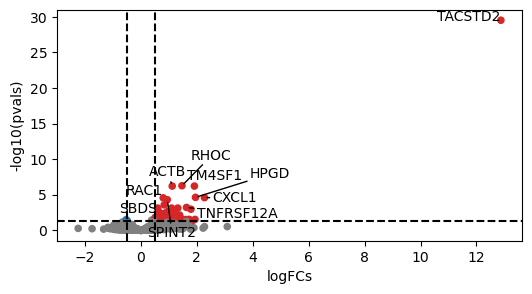

In [33]:
### Plot volcano plot
# Not part of manuscript
print("Plotting results as volcano plot")
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=10,
    figsize=(6, 3),
)

### Enrichment of custom gene sets

In [34]:
# Extract gene set collection from anndata object
print(f"Extract custom gene sets from adata.uns slot")
net = adata.uns['gene_sets']

# Rename for compatibility
net.rename(columns={'gene_set': 'geneset', 'gene': 'genesymbol'}, inplace=True)
net.head(2)

Extract custom gene sets from adata.uns slot


,geneset,genesymbol,weight
0,score_YAP,CXCL10,1
1,score_YAP,ARC,1


In [35]:
# Run gene set network check
import warnings

def pre_network_checks(net, source, target, weight, label):
    ### Network checks
    if source not in net.columns:
        raise ValueError(f"Source column {source} not found in network")
    if target not in net.columns:
        raise ValueError(f"Target column {target} not found in network")
    if weight not in net.columns:
        warnings.warn(f"Weight column {weight} not found in network. Setting to None.")
        weight = None
    # Remove duplicate entries if available
    net = net[~net.duplicated([source, target])]
    # Check if gene list is non-zero
    if net.shape[0] == 0:
        warnings.warn(f"No pathways found in network {label}. Skipping...")
    # Check for each geneset if gene overlap is > 5. Otherwise exclude geneset.
    for geneset in net[source].unique():
        if len(set(net[net[source] == geneset][target]).intersection(adata.var_names)) < 5:
            warnings.warn(f"Skipping {geneset} (less than 5 overlapping genes)")
            net = net[net[source] != geneset]
    # Return if no genesets are left
    if net.shape[0] == 0:
        raise ValueError(f"No pathways found in network {label}. Skipping...")
    else:
        return net


# Define parameters
source='geneset'
target='genesymbol'
weight='weight'
label='custom_gene_sets'

# Run network checks
net = pre_network_checks(
    net, 
    source=source, 
    target=target, 
    weight=weight, 
    label=label
)

/tmp/ipykernel_1419169/1904504389.py:21: UserWarning: Skipping score_Mex3a_Barriga (less than 5 overlapping genes)
  warnings.warn(f"Skipping {geneset} (less than 5 overlapping genes)")


In [36]:
# Subset to gene sets of interest
from utils_treatment_HD4246_SG import custom_subset
if custom_subset is not None:
    # print(f"Subset custom gene sets to {custom_subset}")
    net = net[net['geneset'].isin(custom_subset)] 
    adata.uns['gene_sets'] = net

In [37]:
# Turn DGEA results into anndata object
results_df.reset_index(inplace=True)
results_df.rename(columns={'feature': 'names'}, inplace=True)
df_pivot = results_df.pivot(index='contrast', columns='names', values='stat')
dgea = anndata.AnnData(
    X=df_pivot.values,
    obs=pd.DataFrame(index=df_pivot.index),
    var=pd.DataFrame(index=df_pivot.columns),
)
dgea.raw = dgea

In [38]:
# Run ULM method on custom gene sets
method = "ulm"
print(f"Run enrichment method {method} on custom gene sets")
dc.run_ulm(
    mat=dgea, 
    net=net, 
    source=source, 
    target=target, 
    weight=weight
)
# Extract activity scores as anndata object
acts = dc.get_acts(
    dgea, 
    obsm_key=f'{method}_estimate'
)

Run enrichment method ulm on custom gene sets


In [39]:
### Clean-up activity matrix
# Set activity values of inf to maximum observed
acts_v = acts.X.ravel()
max_e = np.nanmax(acts_v[np.isfinite(acts_v)])
acts.X[~np.isfinite(acts.X)] = max_e

In [40]:
# Extract activity scores and pvalues into DataFrame for plotting
# Activity scores
df = pd.DataFrame(acts.X, columns=acts.var_names, index=acts.obs.index)
df = df.reset_index().melt(id_vars='contrast', var_name='names', value_name='acts')
# p-values
df_pval = pd.DataFrame(acts.obsm[f'{method}_pvals'], columns=acts.var_names, index=acts.obs.index)
df_pval = df_pval.reset_index().melt(id_vars='contrast', var_name='names', value_name='pvalue')
# Merge df and pval_df
df = pd.merge(df, df_pval, on=['contrast', 'names'])        
df = df.sort_values(by='acts', ascending=False)

# Use publication-ready gene set names
from utils_genelist import gs_names_for_pub
df['names'] = df['names'].replace(gs_names_for_pub)

# Report number of significant results
print(f"Number of significant results: {df[df['pvalue'] < 0.05].shape[0]}")
df.to_csv(os.path.join('../data_suppl', f"{accession}_Fig_01h_ULM_acts.csv"))
df

Number of significant results: 15


,contrast,names,acts,pvalue
14,TROP2-pos_vs_TROP2-neg,YAP (Gregorieff et al.),19.956846,1.217425e-87
15,TROP2-pos_vs_TROP2-neg,coreHR (Cañellas-Socias et al.),17.156698,1.908151e-65
1,TROP2-pos_vs_TROP2-neg,Immature enterocytes (Smillie et al.),11.895874,1.656812e-32
12,TROP2-pos_vs_TROP2-neg,score_Revival_SCs_(Vazquez),11.290853,1.838990e-29
16,TROP2-pos_vs_TROP2-neg,epiHR (Cañellas-Socias et al.),10.974578,6.238662e-28
17,TROP2-pos_vs_TROP2-neg,Fetal (Mustata et al.),9.929107,3.579000e-23
11,TROP2-pos_vs_TROP2-neg,score_Revival_SCs_(Ayyaz),8.255499,1.618722e-16
0,TROP2-pos_vs_TROP2-neg,Basal pancreatic cancer cells (Raghavan et al....,6.963425,3.438271e-12
2,TROP2-pos_vs_TROP2-neg,LGR5Hi MEX3AHi (Álvarez-Varela et al.),6.562479,5.439726e-11
3,TROP2-pos_vs_TROP2-neg,LGR5hi MEX3Alow (Álvarez-Varela et al.),5.559093,2.751189e-08


For the manuscript, the bar plot below has been generated using GraphPad Prism. The plot is shown here for transparency reasons including the generation of the underlying data table.

/tmp/ipykernel_1419169/3606191115.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


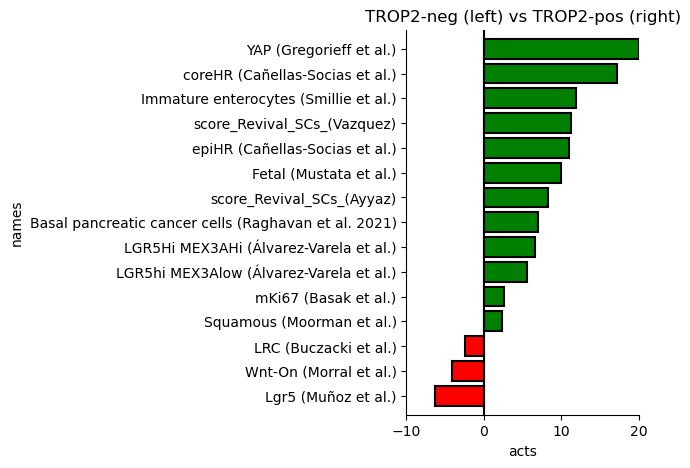

In [47]:
# Make bar plot of significant results
df_sign = df[df['pvalue'] < 0.05].copy()

# Add color group
from utils_treatment_HD4246_SG import color_code
df_sign["direction"] = np.where(df_sign["acts"] > 0, "positive", "negative")
bar_colors = np.where(
    df_sign["acts"] > 0, 
    color_code['TROP2_status']['colors']['positive'], 
    color_code['TROP2_status']['colors']['negative']
)  

height = df_sign.shape[0]/3 if df_sign.shape[0] > 12 else 4
        

fig, ax = plt.subplots(figsize=(3, height))
dc.plot_barplot_df(
    df_sign,
    x="acts",
    y="names",
    color=bar_colors[::-1],
    title="TROP2-neg (left) vs TROP2-pos (right)",
    figsize=(3, height),
    ax=ax,
)
# Add outer line to bars
for patch in ax.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)

ax.axvline(x=0, color='black')
ax.set_xlim(-10, 20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [42]:
session_info.show()

/omics/groups/OE0285/internal/puschhof/envs/env_saez/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
